In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, norm
from scipy import stats

import torch
import torch.nn as nn
from dataset_creation import create_synthetic_supernovae_dataset, create_torch_supernovae_dataset, z_obs

from SupernovaDataset.config import DATAPOINT_SIZE, LATENT_SIZE, BETA, REGULARIZATION_WEIGHT, DATA_VARIANCE_SCALE, NUM_TRAIN, NUM_TEST, LOAD_DATASET

from Compression.ib import IB
from Compression.compressors import IBCompressor
from Compression.conditional_prob_models import ConditionalKDE, ConditionalNormalizingFlow
from Compression.mine import Mine

from Compression.Benchmarks.MOPED import moped

from ModelEvaluation.posterior_comparison import evaluate_posterior_covariance
from ModelEvaluation.abc import abc_testing
from ModelEvaluation.coverage_testing import coverage_tests

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Running on device:", device)
# torch.cuda.is_available()

Running on device: cuda


In [4]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.12.0+cu132
13.2
True


## Generating a dataseet

In [5]:
# LOAD_DATASET = False

In [6]:
if LOAD_DATASET:
    try:
        train_sims_data = torch.load("train_sims_data.pt")
        test_sims_data = torch.load("test_sims_data.pt")
    except FileNotFoundError:
        print("Data files not found. Creating dataset...")
        train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
        torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
        torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")
else:
    train_sims_data, test_sims_data, _ = create_torch_supernovae_dataset(NUM_TRAIN, NUM_TEST)
    torch.save(train_sims_data.to('cpu'), "train_sims_data.pt")
    torch.save(test_sims_data.to('cpu'), "test_sims_data.pt")

train_sims_data = train_sims_data.to(device)
test_sims_data = test_sims_data.to(device)

## Visualizing the dataset

### Spread of the data with Hubble Parameter
In order to visualize the fact that our data simply moves by a global offset based on the Hubble Constant, we visualize the mean of the data with the Hubble Parameter. This forms quite a linear scatter, showing that the mean is a good representation of the parameter here!

### Each individual datapoint
Each individual datapoint retains the same shape, and only its offset depends on the Hubble constant (can be seen by re-running the cell multiple times and seeing that the shape is retained...alternatively, I can plot all the data-points and subtract their means)  
We notice that the points at low redshift scatter less than those at higher redshifts. This is expected as the lower flux due to the higher redshift appears as a larger scatter

In [7]:
mu = train_sims_data[:, :DATAPOINT_SIZE].detach().cpu()
h0 = train_sims_data[:, -1].detach().cpu()

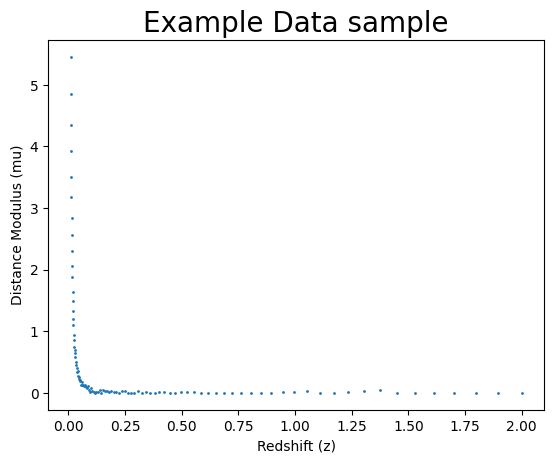

In [8]:
obs_no = np.random.randint(NUM_TRAIN)
flux_obs = 10**(-0.4*mu[obs_no, :])
mu_obs = mu[obs_no, :]
plt.scatter(z_obs, mu_obs, s=1)
# plt.scatter(z_obs, mu_noiseless[obs_no, :], color='red', label='True Signal')
plt.xlabel("Redshift (z)")
plt.ylabel("Distance Modulus (mu)")
# plt.title(f"Obs: {obs_no} | H0: {h0[obs_no]:.2f}")
plt.title('Example Data sample', fontsize=20)
plt.show()

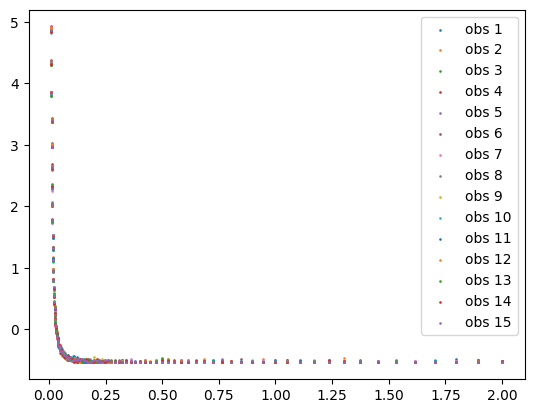

In [9]:
mu_zero_mean = mu - torch.mean(mu, axis=1)[:, None]
mu_zero_mean.shape

for i in range(15):
    plt.scatter(z_obs, mu_zero_mean[i, :], s=0.75, label=f'obs {i+1}')
plt.legend()
plt.show()

## Compression

In [10]:
class Compressor(nn.Module):
    def __init__(self, input_size=DATAPOINT_SIZE, latent_size=LATENT_SIZE):
        super(Compressor, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_size, 1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),
            
            nn.Linear(32, 2*latent_size)
        )

    def forward(self, x):
        return self.encoder(x)

In [11]:
model_encoder=Compressor()
model = IB(
    encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
    # cond_prob_model=ConditionalKDE(1, 2),
    cond_prob_model=Mine(1, LATENT_SIZE, alpha=1e-1),
    beta = 0,
    reg_weight=4e-2,
    reg_type=0,
    optim_func=torch.optim.Adam,
    lr=1e-4
).to(device)
h02s = train_sims_data[:, -1:]
h02_norm = (h02s - h02s.mean()) / h02s.std()

In [12]:
model.train(
    x_train=train_sims_data[:, :DATAPOINT_SIZE],
    y_train=h02_norm,
    nepochs=500,
    batch_size=512,
    print_losses=True
    )

assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

Epoch 1: Loss=-51.4297, log_q=51.4653,, reg. loss=0.0356, beta * KL=0.5054
Epoch 10: Loss=-20.2345, log_q=20.2704,, reg. loss=0.0359, beta * KL=0.5142
Epoch 20: Loss=-21.5220, log_q=21.5595,, reg. loss=0.0375, beta * KL=0.5142
Epoch 30: Loss=-21.1422, log_q=21.1793,, reg. loss=0.0370, beta * KL=0.5142
Epoch 40: Loss=-21.7951, log_q=21.8325,, reg. loss=0.0374, beta * KL=0.5142
Epoch 50: Loss=-21.8078, log_q=21.8438,, reg. loss=0.0359, beta * KL=0.5142
Epoch 60: Loss=-22.6684, log_q=22.7052,, reg. loss=0.0368, beta * KL=0.5142
Epoch 70: Loss=-20.9362, log_q=20.9728,, reg. loss=0.0366, beta * KL=0.5142
Epoch 80: Loss=-20.9518, log_q=20.9889,, reg. loss=0.0371, beta * KL=0.5142
Epoch 90: Loss=-21.3060, log_q=21.3424,, reg. loss=0.0364, beta * KL=0.5142
Epoch 100: Loss=-21.2639, log_q=21.3013,, reg. loss=0.0374, beta * KL=0.5142
Encoder becomes nans first
Mean: tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
   

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
zs = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu()
z_min = zs.min()
z_max = zs.max()

print(f"Latent space range: min={z_min:.4f}, max={z_max:.4f}")

z_values = torch.linspace(z_min, z_max, 500)
y_values = torch.linspace(69.8**2, 70.2**2, 500)
yz_values = torch.cartesian_prod(z_values, y_values).to(device)
mine_values = model.cond_prob_model(yz_values[:, 1:], yz_values[:, 0:1]).detach().cpu().numpy()

Latent space range: min=9.3858, max=9.8205


(array([1933.,    7.,   12.,   10.,    5.,    5.,    4.,    5.,    9.,
          10.]),
 array([-6.53839111e-03,  1.18715591e+00,  2.38085022e+00,  3.57454453e+00,
         4.76823883e+00,  5.96193314e+00,  7.15562744e+00,  8.34932175e+00,
         9.54301605e+00,  1.07367104e+01,  1.19304047e+01]),
 <BarContainer object of 10 artists>)

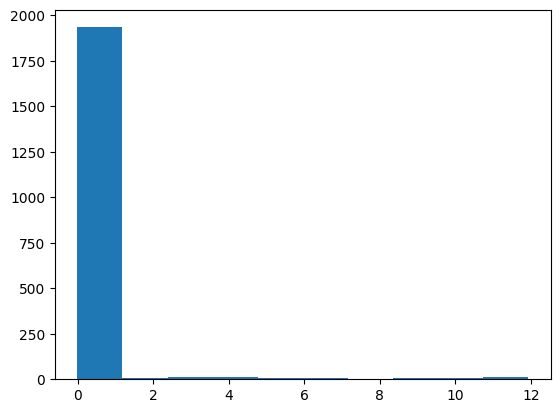

In [ ]:
plt.hist(model.log_prob_losses)

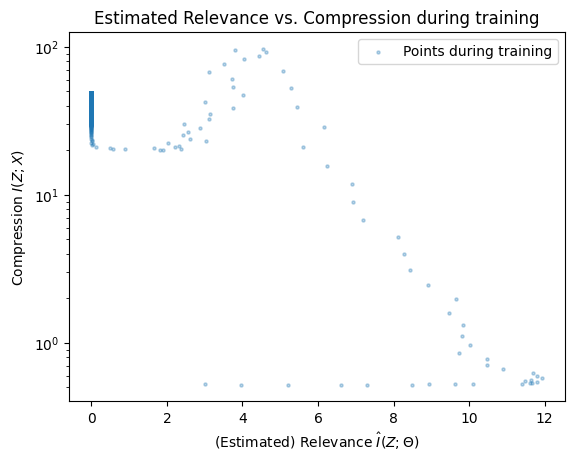

In [ ]:
plt.scatter(np.array(model.log_prob_losses), np.array(model.kl_losses), alpha=0.3, s=5e0,
            label='Points during training')
# plt.axvline(
#     x = 8.64,
#     color='red',
#     linestyle='--',
#     linewidth=1,
#     label=r'Full dataset $I(X; \Theta)$'
# )
# plt.axvline(
#     x = 8.64 - 3.02,
#     color='green',
#     linestyle='--',
#     linewidth=1,
#     label=r'Expected model to learn $\hat{I}(X; \Theta)$'
# )

plt.yscale('log')
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

Training new model iteration 1...
Epoch 1: Loss=484.0765, log_q=-484.0410,, reg. loss=0.0355, beta * KL=0.5464
Epoch 10: Loss=9.0078, log_q=-9.0071,, reg. loss=0.0008, beta * KL=327.6414
Epoch 20: Loss=8.9887, log_q=-8.9877,, reg. loss=0.0010, beta * KL=428.3685
Epoch 30: Loss=8.9796, log_q=-8.9785,, reg. loss=0.0011, beta * KL=485.8763
Epoch 40: Loss=8.9704, log_q=-8.9692,, reg. loss=0.0012, beta * KL=532.9103
Epoch 50: Loss=8.9599, log_q=-8.9585,, reg. loss=0.0013, beta * KL=591.3045
Epoch 60: Loss=8.9465, log_q=-8.9449,, reg. loss=0.0016, beta * KL=687.9175
Epoch 70: Loss=8.9268, log_q=-8.9248,, reg. loss=0.0020, beta * KL=888.9590
Epoch 80: Loss=8.8865, log_q=-8.8831,, reg. loss=0.0035, beta * KL=1517.0237
Epoch 90: Loss=8.3675, log_q=-8.2857,, reg. loss=0.0818, beta * KL=35196.6795
Epoch 100: Loss=8.6620, log_q=-8.6142,, reg. loss=0.0478, beta * KL=21402.8813
Epoch 110: Loss=8.6519, log_q=-8.6116,, reg. loss=0.0403, beta * KL=18246.0441
Epoch 120: Loss=8.6426, log_q=-8.6087,, reg.

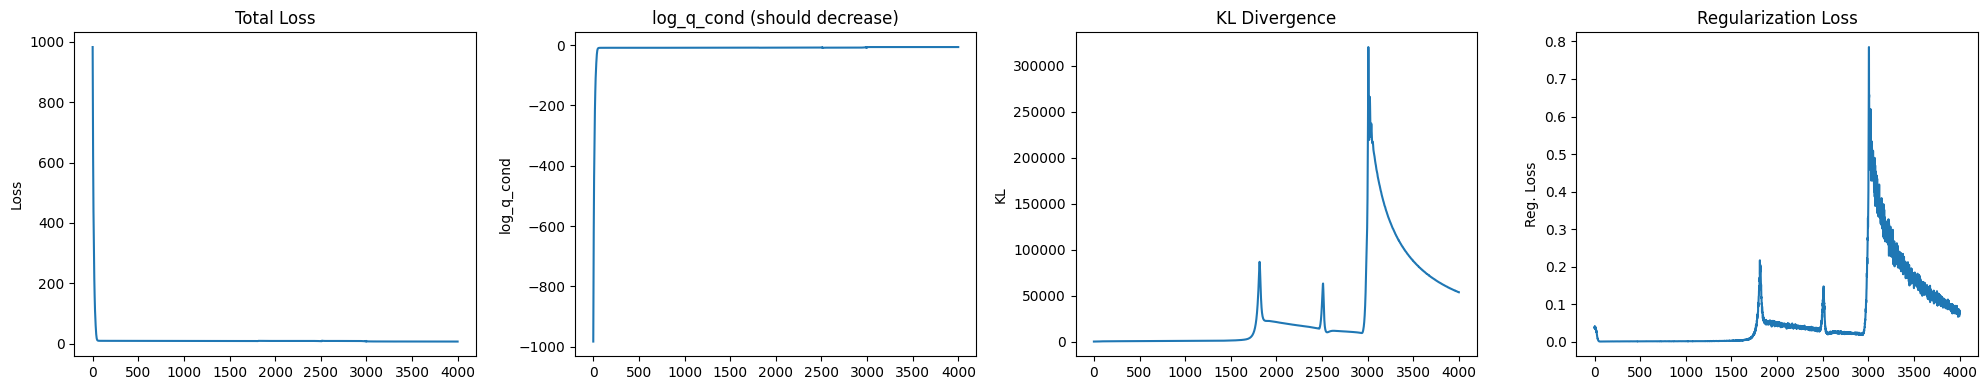

Training new model iteration 2...
Epoch 1: Loss=566.1226, log_q=-566.0833,, reg. loss=0.0393, beta * KL=0.5240
Epoch 10: Loss=9.0257, log_q=-9.0081,, reg. loss=0.0176, beta * KL=91.0494
Epoch 20: Loss=8.9989, log_q=-8.9929,, reg. loss=0.0060, beta * KL=107.3311
Epoch 30: Loss=8.9872, log_q=-8.9846,, reg. loss=0.0027, beta * KL=120.6044
Epoch 40: Loss=8.9792, log_q=-8.9776,, reg. loss=0.0016, beta * KL=131.0925
Epoch 50: Loss=8.9716, log_q=-8.9706,, reg. loss=0.0010, beta * KL=140.7559
Epoch 60: Loss=8.9636, log_q=-8.9628,, reg. loss=0.0008, beta * KL=151.5503
Epoch 70: Loss=8.9546, log_q=-8.9539,, reg. loss=0.0007, beta * KL=166.2928
Epoch 80: Loss=8.9434, log_q=-8.9428,, reg. loss=0.0006, beta * KL=190.4241
Epoch 90: Loss=8.9269, log_q=-8.9262,, reg. loss=0.0006, beta * KL=242.7996
Epoch 100: Loss=8.8854, log_q=-8.8844,, reg. loss=0.0010, beta * KL=452.2246
Epoch 110: Loss=8.5393, log_q=-8.5255,, reg. loss=0.0138, beta * KL=5971.3502
Epoch 120: Loss=8.6344, log_q=-8.6091,, reg. loss=0

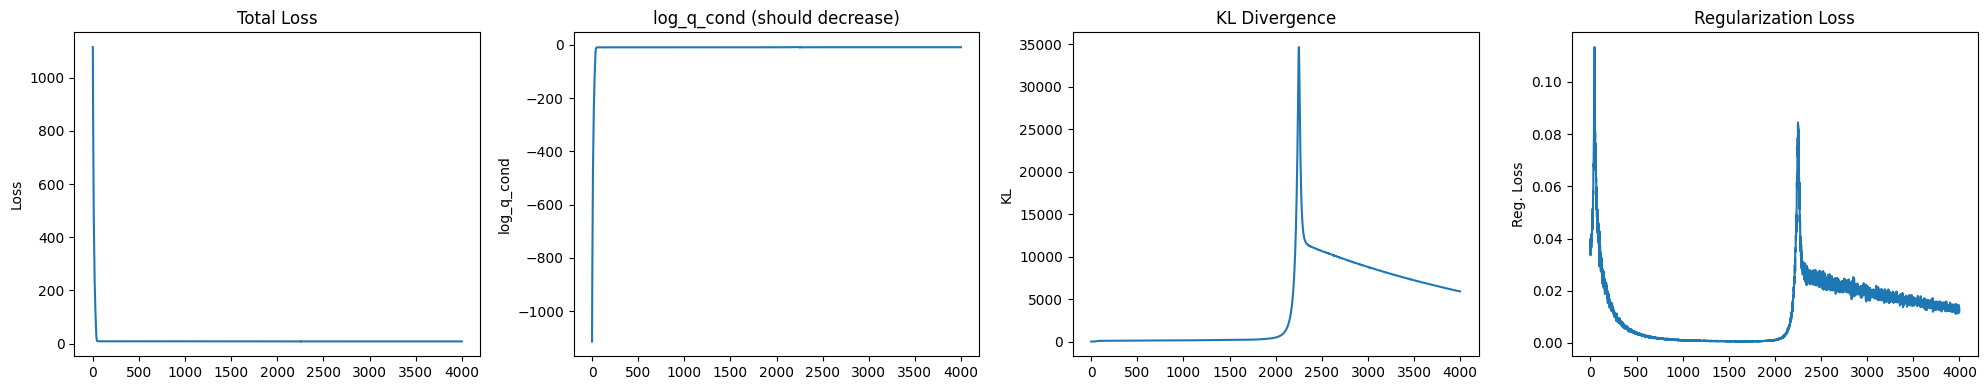

Training new model iteration 3...
Epoch 1: Loss=486.7350, log_q=-486.6888,, reg. loss=0.0463, beta * KL=0.5309
Epoch 10: Loss=9.0069, log_q=-9.0036,, reg. loss=0.0033, beta * KL=238.1683
Epoch 20: Loss=8.9856, log_q=-8.9838,, reg. loss=0.0017, beta * KL=290.2141
Epoch 30: Loss=8.9748, log_q=-8.9736,, reg. loss=0.0012, beta * KL=325.5449
Epoch 40: Loss=8.9646, log_q=-8.9636,, reg. loss=0.0011, beta * KL=357.3195
Epoch 50: Loss=8.9531, log_q=-8.9521,, reg. loss=0.0011, beta * KL=397.0468
Epoch 60: Loss=8.9388, log_q=-8.9376,, reg. loss=0.0011, beta * KL=460.7244
Epoch 70: Loss=8.9182, log_q=-8.9169,, reg. loss=0.0013, beta * KL=584.8811
Epoch 80: Loss=8.8808, log_q=-8.8787,, reg. loss=0.0021, beta * KL=911.7600
Epoch 90: Loss=8.7478, log_q=-8.7411,, reg. loss=0.0068, beta * KL=2969.9138
Encoder becomes nans first
Mean: tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [Tr

TypeError: cannot unpack non-iterable NoneType object

In [ ]:
# ba_bounds = []
# i_z_x = []
for i in range(10):
    print(f"Training new model iteration {i+1}...")
    model_encoder=Compressor()
    model = IB(
        encoder=IBCompressor(encoder=model_encoder, x_dim=DATAPOINT_SIZE, z_dim=LATENT_SIZE),
        # cond_prob_model=ConditionalKDE(1, 10),
        cond_prob_model=ConditionalNormalizingFlow(),
        beta = 0e-1,
        reg_weight=4e-2,
        reg_type=0,
        optim_func=torch.optim.Adam,
        lr=1e-4
    ).to(device)

    model.train(
        x_train=train_sims_data[:, :DATAPOINT_SIZE],
        y_train=train_sims_data[:, -1],
        nepochs=200,
        batch_size=512,
        print_losses=True
        )
    assert not np.isnan(model.full_losses[-1]), "Total loss is NaN. Check the model and training process."

    ba_bounds = ba_bounds + model.log_prob_losses
    i_z_x = i_z_x + model.kl_losses

plt.scatter(-1*np.array(ba_bounds), i_z_x, alpha=0.5, s=1e0,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

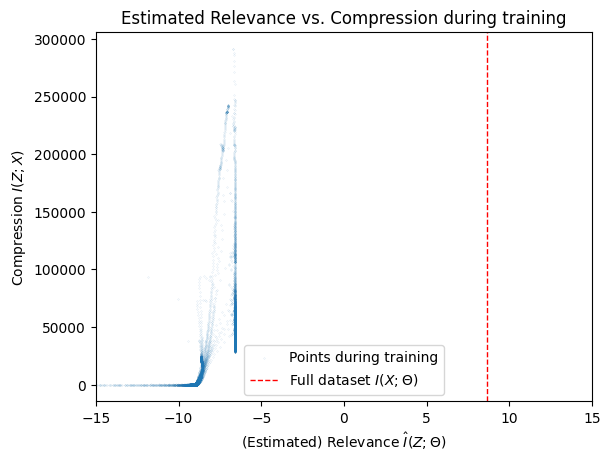

In [ ]:
plt.scatter(np.array(ba_bounds), i_z_x, alpha=0.5, s=1e-2,
            label='Points during training')
plt.axvline(
    x = 8.64,
    color='red',
    linestyle='--',
    linewidth=1,
    label=r'Full dataset $I(X; \Theta)$'
)
plt.xlim([-15, 15])
plt.xlabel(r"(Estimated) Relevance $\hat{I}(Z;\Theta)$")
plt.ylabel(r"Compression $I(Z;X)$")
plt.legend()
plt.title('Estimated Relevance vs. Compression during training')
plt.show()

In [ ]:
np.save("dv_bounds.npy", -1*np.array(ba_bounds), allow_pickle=True)
np.save("i_z_x.npy", i_z_x, allow_pickle=True)

## Plotting the results to compare estimator std dev

-2.3675222 -2.4686599


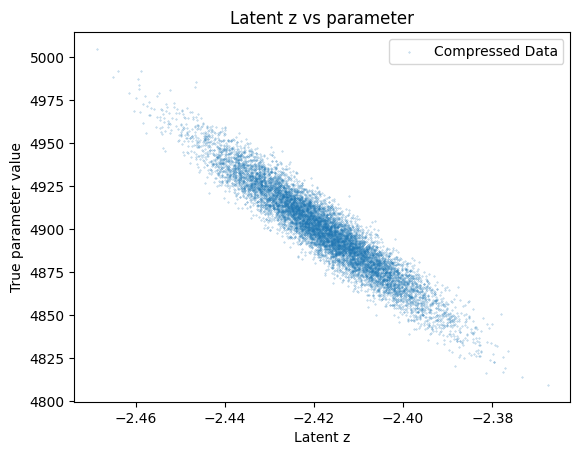

In [ ]:
m, l, z = model.encoder(train_sims_data[:, :DATAPOINT_SIZE])
m = m.detach().cpu().numpy()

print(m.max(), m.min())

plt.scatter(m, train_sims_data[:, -1].cpu().numpy(), alpha=0.5, s=1e-1, label='Compressed Data')
plt.xlabel('Latent z')
plt.ylabel('True parameter value')
plt.legend()
# plt.xlim([110, 120])
plt.title('Latent z vs parameter')
plt.show()

In [ ]:
# To check if the model collapsed: the standard deviations in m must match the priors
m.std(), l.std()


(np.float32(0.012811277),
 tensor(0.0110, device='cuda:0', grad_fn=<StdBackward0>))

Dataset size: 50000, Number of bins: 11, Bin width: 0.00
Bin centers: [-2.4712825 -2.4607406 -2.4501987 -2.4396572 -2.4291153 -2.4185736
 -2.408032  -2.39749   -2.3869486 -2.3764067 -2.3658648]
Bin means: [nan, 4978.697265625, 4959.4482421875, 4940.28759765625, 4920.37451171875, 4900.77685546875, 4881.6103515625, 4862.0751953125, 4842.96044921875, 4816.13623046875, 4798.94677734375]
Bin stds: [nan, 5.377106189727783, 7.595717906951904, 8.070244789123535, 8.020166397094727, 8.061893463134766, 7.908627510070801, 7.741042137145996, 7.628408432006836, 6.218008518218994, 0.0]
Bin stds errors: [nan, np.float64(1.3442765474319458), np.float64(0.5791680607299649), np.float64(0.2739219568216541), np.float64(0.1616364689853341), np.float64(0.13366130817338637), np.float64(0.1508664797789941), np.float64(0.24503840721628117), np.float64(0.5850722187977309), np.float64(1.390388973141041), nan]


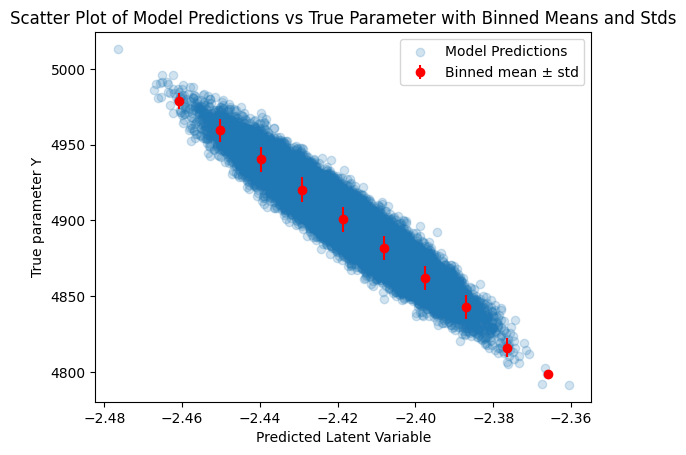

(np.float64(7.955356770709213),
 array([5.37710619, 7.59571791, 8.07024479, 8.0201664 , 8.06189346,
        7.90862751, 7.74104214, 7.62840843, 6.21800852]),
 array([1.34427655, 0.57916806, 0.27392196, 0.16163647, 0.13366131,
        0.15086648, 0.24503841, 0.58507222, 1.39038897]))

In [ ]:
sigma_beta, _, std, std_err = evaluate_posterior_covariance(model, test_sims_data[:, :DATAPOINT_SIZE], test_sims_data[:, -1:])
sigma_beta, std, std_err

## Posterior comparison

In [ ]:
SELECT_PERCENT = 0.125e-3
show_h0_instead_of_h02 = False

In [ ]:
true_h02 = 69.95**2
# true_h0 = test_sims_data[0, -1].item()
_, data_obs, _, _ = create_synthetic_supernovae_dataset(n_samples=1, h02s=[true_h02])
data_obs = torch.tensor(data_obs, dtype=torch.float32).to(device)

y_data_abc = test_sims_data[:, -1:].detach().cpu()
shown_true_param = true_h02
param_name = '$H_0^2$' if not show_h0_instead_of_h02 else '$H_0$'

if show_h0_instead_of_h02:
    y_data_abc = torch.sqrt(y_data_abc)
    shown_true_param = np.sqrt(true_h02)


Creating sample: 1 of 1


Compressed obs: -2.4177558422088623
Selected 1912 samples from test set with compressed value close to observed compressed value.


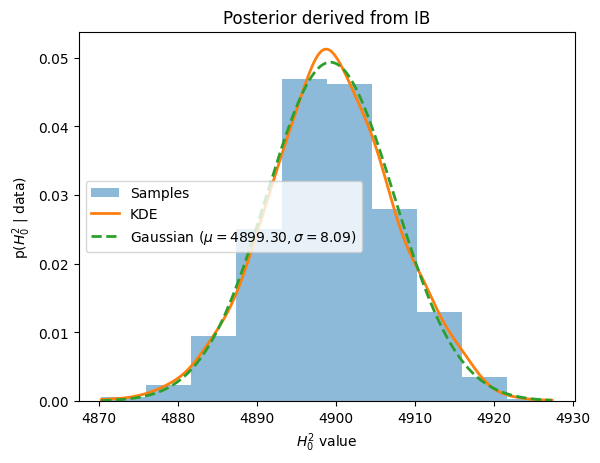

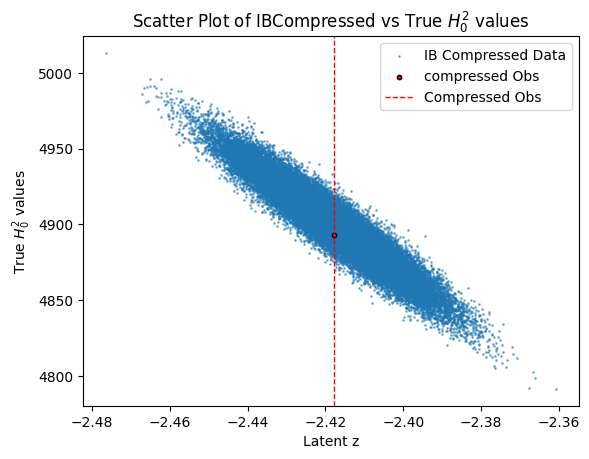

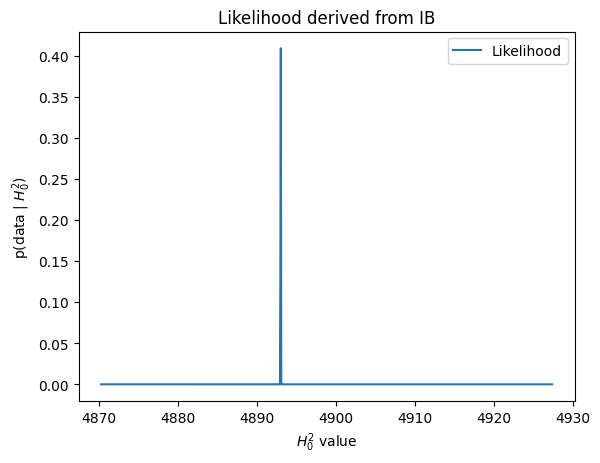

((np.float32(4899.2993), np.float32(8.085845)),
 0.778752863407135,
 0.20868200836820083,
 1912)

In [ ]:
compressed_test = model(test_sims_data[:, :DATAPOINT_SIZE]).detach().cpu().numpy()

compressed_obs = model(data_obs).detach().cpu().numpy()

print("Compressed obs:", compressed_obs.item())

abc_testing(compressed_obs, compressed_test, 
            y_data=y_data_abc,
            true_param=shown_true_param,
            param_name=param_name,
            method_name='IB')

### MOPED Compression

Creating sample: 1 of 1
Creating sample: 1 of 1
Creating sample: 1 of 1
(1, 100)
MOPED Fisher information: [[1.6e-07]]


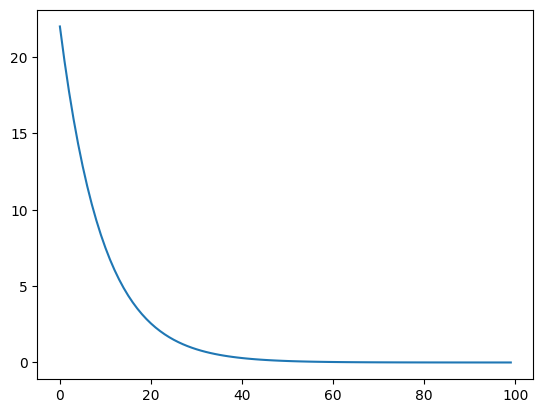

In [ ]:
cov = np.eye(DATAPOINT_SIZE) * DATA_VARIANCE_SCALE**2

def estimator_given_theta(theta):
    _, data, _, _ = create_synthetic_supernovae_dataset(1, theta, data_var=0.)
    # print(data.shape)
    # return 10**(-0.4*data[0, :])
    return data[0, :]

fid_vals = np.array([70.0**2])

b, F, d = moped(fid_vals, cov, estimator_given_theta)
# print("MOPED compressed value:", b)
print("MOPED Fisher information:", 1/F)
plt.plot(b.T)
plt.show()

In [ ]:
def moped_model(data):
    if (type(data) != np.ndarray):
        data = data.detach().cpu().numpy()
    return data[:, :DATAPOINT_SIZE] @ b.T
moped_compressed = moped_model(data_obs)
moped_test = moped_model(test_sims_data)
moped_compressed

array([[615.1304487]])

Selected 1834 samples from test set with compressed value close to observed compressed value.


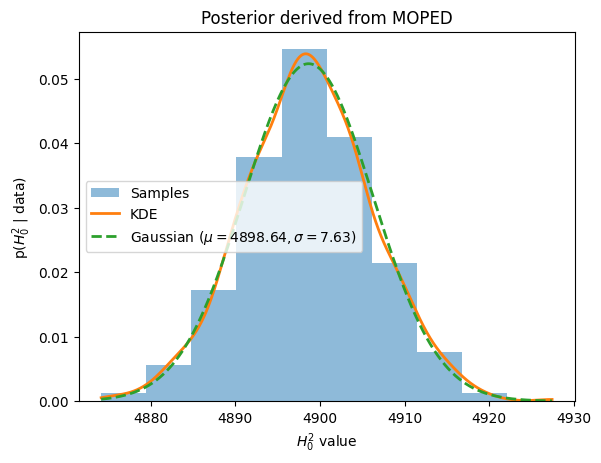

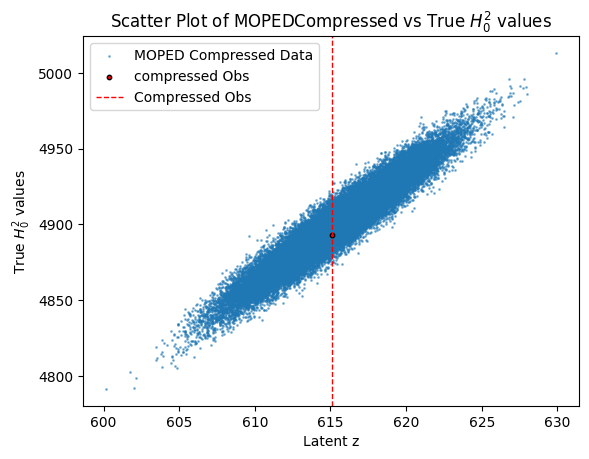

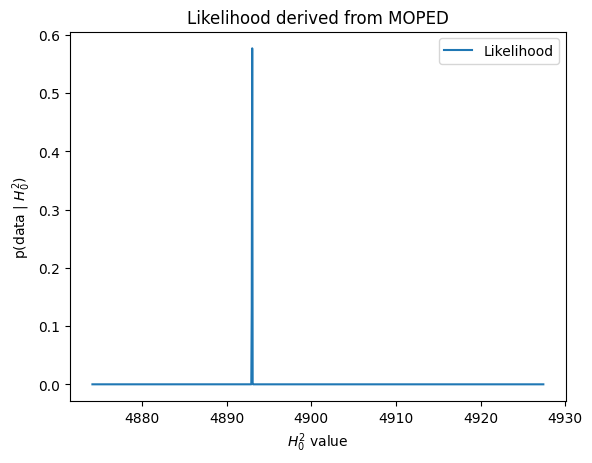

((np.float32(4898.6416), np.float32(7.628632)),
 0.7392098903656006,
 0.23336968375136313,
 1834)

In [ ]:
abc_testing(moped_compressed, moped_test, y_data_abc, true_param=shown_true_param)

# Coverage Testing

In [ ]:
z_scores, pit_values= coverage_tests(10000, model, test_sims_data, "IB")

Creating sample: 10000 of 10000
Creating sample: 1 of 1
No samples selected


TypeError: cannot unpack non-iterable int object

Creating sample: 10000 of 10000
Creating sample: 1 of 1


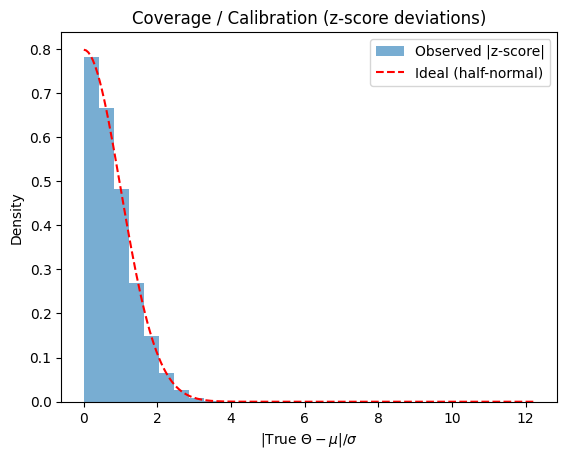

Fraction within 1σ: 0.691  (ideal ≈ 0.683)
Fraction within 2σ: 0.954  (ideal ≈ 0.954)


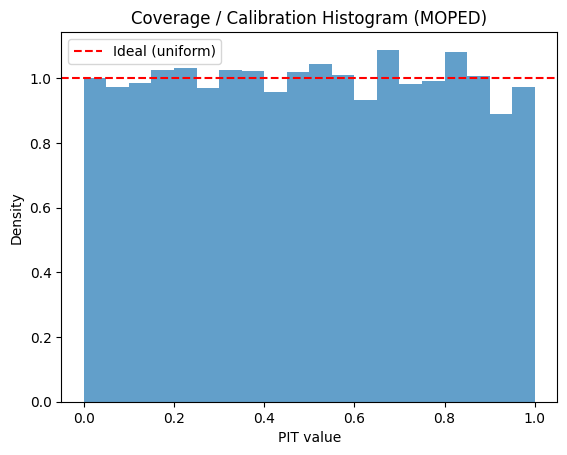

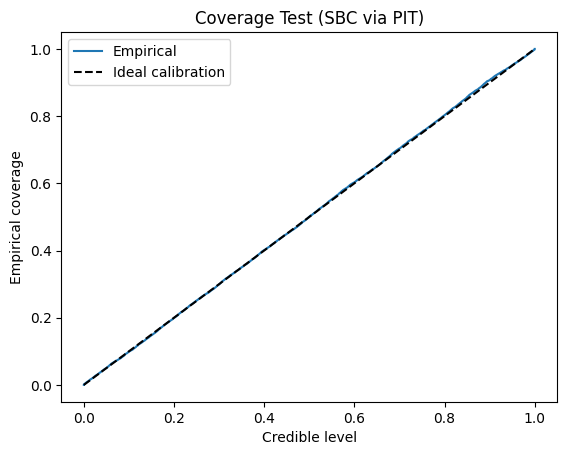

(array([0.31535804, 0.38267443, 1.90499687, ..., 0.07971231, 0.00613015,
        0.42222652], shape=(10000,)),
 array([0.62305296, 0.33978133, 0.03722084, ..., 0.52534562, 0.49521531,
        0.33973655], shape=(10000,)))

In [ ]:
coverage_tests(10000, moped_model, test_sims_data, "MOPED")